<a href="https://colab.research.google.com/github/monroeu/MG628/blob/main/MG628_Week5_Descriptive_Analytics_Colab_EXPANDED.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MG628 · Week 5 | Descriptive Analytics and Statistics
### A hands-on Excel ↔ Python laboratory for managerial decision-making

**Big question:** *How can managers describe what happened in a business or healthcare operation, determine whether performance is typical or volatile, and communicate what to investigate next?*

This notebook combines three different data contexts:

| Dataset | What it represents | How we use it |
|---|---|---|
| `sales_week5.csv` | 200 sales observations | Main business case: revenue, product frequencies, distributions and outliers |
| `healthcare_week5.csv` | 50 healthcare observations | Transfer case: admissions, billing and variability across departments |
| `synthetic_distributions.csv` | 400 deliberately generated examples | Controlled demonstrations of normality, skewness and kurtosis—not real customers or patients |

**Learning outcomes.** By the end, you should be able to (1) check data quality; (2) compute and explain center, frequency, variability and distribution shape; (3) interpret a histogram and box plot; (4) reproduce sample statistics in Excel and Python; and (5) propose a responsible managerial follow-up without confusing description with causation.

**The analytic cycle:** **Managerial question → inspect data → choose statistic → calculate → visualize → interpret → recommend what to investigate**. We are learning to make evidence-based decisions, not simply to generate a table of numbers.

> **Notation used throughout:** $x_i$ is an individual observed value; $n$ is the sample size; $\bar{x}$ is the sample mean; $s$ is the sample standard deviation; $Q_1$ and $Q_3$ are the first and third quartiles. When formulas refer to the entire population, we use $N$, $\mu$ and $\sigma$. Unless otherwise noted, monetary variables are in US dollars.

**Teaching workflow:** Read each concept explanation, predict what you expect to see, run the next code cell, inspect its output, then answer the managerial interpretation question before continuing.

## 1. Preparing the datasets: reproducible data loading

### Concept: why does reproducibility matter?

An analysis is **reproducible** when another person can use the same data, definitions and code to get the same results. In business analytics, reproducibility lets a manager verify an important KPI instead of accepting an unexplained number on a dashboard. A small filename difference can prevent any analysis from running—and mixing an old dataset with a new one can produce *plausible but incorrect* conclusions.

A **DataFrame** is a rectangular data table in pandas. Each row represents an observation, and each column represents a variable. The cells below create three DataFrames named `sales`, `health` and `distributions`. All later examples depend on those names.

**File setup in Colab:** The first code cell expects `sales_week5.csv`, `healthcare_week5.csv` and `synthetic_distributions.csv` in Colab's `/content` directory. You can confirm the names by opening the **Files** sidebar. If you uploaded the same file twice, Colab may also display a second copy with `(1)` in its name; the notebook uses the unnumbered copy. **The code does not require another upload if the originals are already present.**

**What the first cell checks:**

- Existence of each required CSV.
- Expected number of rows: 200 sales, 50 healthcare and 400 synthetic examples.
- Presence of the seven required sales columns, including `Total Revenue`.
- First five records from each dataset, so the column types and values are visible.

A successful import is only the **first** quality check: even a perfectly readable CSV may contain duplicates, missing values or implausible numbers.

**Excel connection:** **Data → Get Data → From Text/CSV** imports a CSV into an Excel worksheet. A careful analyst then confirms headers, data types and row counts in either application.

**Before running:** Predict what happens if one dataset has 199 rows rather than 200. Why is an explicit assertion better than silently continuing?

In [5]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# MG628 WEEK 5 - LOAD DATA DIRECTLY FROM GITHUB
# =====================================================

BASE_URL = (
    "https://raw.githubusercontent.com/"
    "monroeu/MG628/main/week05/data/"
)

sales_url = BASE_URL + "sales_week5.csv"
health_url = BASE_URL + "healthcare_week5.csv"
distributions_url = BASE_URL + "synthetic_distributions.csv"

# Read CSV files directly from GitHub
sales = pd.read_csv(sales_url)
health = pd.read_csv(health_url)
distributions = pd.read_csv(distributions_url)

# =====================================================
# VERIFY DATA LOADING
# =====================================================

print("MG628 WEEK 5 - DATA LOADING SUCCESSFUL")
print("=" * 50)

print(f"Sales records: {len(sales)}")
print(f"Healthcare records: {len(health)}")
print(f"Distribution records: {len(distributions)}")

# Validate record counts
assert len(sales) == 200, "Expected 200 sales records."
assert len(health) == 50, "Expected 50 healthcare records."
assert len(distributions) == 400, "Expected 400 distribution records."

# Validate sales columns
required_columns = {
    "Date", "Product", "Region", "Salesperson",
    "Units Sold", "Unit Price", "Total Revenue"
}

missing = required_columns - set(sales.columns)

if missing:
    raise ValueError(
        f"Missing sales columns: {sorted(missing)}"
    )

print("\nAll validation checks passed!")

# Preview datasets
print("\nSALES DATASET")
display(sales.head())

print("\nHEALTHCARE DATASET")
display(health.head())

print("\nSYNTHETIC DISTRIBUTIONS")
display(distributions.head())


MG628 WEEK 5 - DATA LOADING SUCCESSFUL
Sales records: 200
Healthcare records: 50
Distribution records: 400

All validation checks passed!

SALES DATASET


,Date,Product,Region,Salesperson,Units Sold,Unit Price,Total Revenue
0,3/4/2023,Smartphone,North,Diana,43,449.96,19348.28
1,2/2/2023,Keyboard,East,Diana,19,750.65,14262.35
2,1/26/2024,Laptop,West,Charlie,14,1214.30,17000.20
3,4/20/2023,Tablet,South,Alice,18,572.33,10301.94
4,8/7/2023,Keyboard,North,Diana,48,65.47,3142.56



HEALTHCARE DATASET


,Department,Facility,Physician_ID,Patient_Admissions,Average_Cost_per_Patient,Total_Billing
0,Oncology,Downtown Campus,DR-008,12,2314.68,27776.16
1,Orthopedics,North Clinic,DR-004,18,1492.53,26865.54
2,Pediatrics,North Clinic,DR-003,25,2382.80,59570.00
3,Orthopedics,Downtown Campus,DR-003,8,1416.10,11328.80
4,Orthopedics,West Medical Center,DR-018,15,4282.04,64230.60



SYNTHETIC DISTRIBUTIONS


,Normal,Right_Skew,Left_Skew,Mesokurtic,Leptokurtic,Platykurtic
0,84.119285,95.735644,109.689884,0.743155,1.181587,0.875598
1,88.760795,83.050175,103.546060,-0.226385,0.346332,-0.460117
2,124.770927,135.747014,91.473266,0.064348,-0.265151,-1.385886
3,100.191486,139.867379,88.510401,0.033467,0.397424,0.625458
4,71.289790,83.240027,103.340813,0.760116,-0.152839,-0.579257


## 2. The data-quality gate: trustworthy statistics require trustworthy inputs

### Concept: “garbage in, garbage out”

A mean or chart can be mathematically correct yet operationally misleading if its underlying records are wrong. Descriptive analytics begins with **validity, completeness, uniqueness and consistency**:

| Quality dimension | Question to ask | Possible consequence |
|---|---|---|
| Completeness | Are values missing? | The mean uses fewer observations than expected |
| Uniqueness | Were transactions accidentally duplicated? | Revenue and counts can be overstated |
| Validity | Are units, dates and revenue values plausible? | Extreme or impossible values distort spread |
| Consistency | Are categories spelled consistently? | A frequency table may split the same product into multiple groups |
| Reconciliation | Does `Units Sold × Unit Price` agree with `Total Revenue`? | A derived KPI may not match source-system rules |

The next cell prints the number of missing values per sales column, counts exactly duplicated rows, and previews units, prices and reported revenue. **A missing-value count of zero does not prove that the source is correct.** Some systems encode missing information as a blank string, `0`, `N/A` or a special code.

### Revenue reconciliation example

If a transaction sells **4 units at $25.00**, a simple gross-revenue calculation is

$$4\times\$25.00=\$100.00.$$

But a system could legitimately report less after a discount or refund. Investigate differences *before* replacing recorded values; you must know the business definition of `Total Revenue`.

**Excel counterpart:** Use **Data → Remove Duplicates** only after creating an auditable copy; use `=COUNTBLANK(range)` for missing cells and `=E2*F2` to calculate a row's expected revenue, adjusting references to your sheet.

**Think like a manager:** What action would you take if one unusually large sale appears in the data—delete it immediately, or verify its supporting transaction? Why?

In [6]:
print(sales.isna().sum().to_string())
print('Duplicates:',sales.duplicated().sum())
print('Healthcare missing values:',int(health.isna().sum().sum()))
print('Revenue sample:', sales[["Product","Units Sold","Unit Price","Total Revenue"]].head().to_string(index=False))

Date             0
Product          0
Region           0
Salesperson      0
Units Sold       0
Unit Price       0
Total Revenue    0
Duplicates: 0
Healthcare missing values: 0
Revenue sample:    Product  Units Sold  Unit Price  Total Revenue
Smartphone          43      449.96       19348.28
  Keyboard          19      750.65       14262.35
    Laptop          14     1214.30       17000.20
    Tablet          18      572.33       10301.94
  Keyboard          48       65.47        3142.56


## 3. Measures of central tendency: mean, median and mode

The **center** answers: *What is a representative or typical observation?* No single measure of center is best for every dataset.

### Arithmetic mean (average)

The sample mean is

$$\bar{x}=\frac{\sum_{i=1}^{n}x_i}{n}.$$

The mean uses every numeric value, making it intuitive for budgeting and totals-per-transaction calculations. Its weakness is **sensitivity to extreme observations**.

### Median (50th percentile)

Sort observations from smallest to largest. The **median** is the middle value when $n$ is odd; when $n$ is even, it is the average of the two middle values. Because its location matters more than the magnitude of the extremes, the median is often more informative for skewed transaction values, home prices and waiting times.

### Mode (most frequent value)

The **mode** identifies the most common value. It is especially useful for **categories** such as product type or region. Numeric data may have several modes or no repeated value; reporting a mode for nearly unique transaction revenues may not be meaningful.

### Worked example: one extreme service time

Consider five service times (minutes): **45, 48, 50, 52, 205**.

$$\text{Mean}=\frac{45+48+50+52+205}{5}=80\text{ minutes}.$$

The sorted middle observation is **50**, so the **median is 50 minutes**. Four of the five customers were served within 45–52 minutes; one 205-minute wait raises the mean substantially. A manager should report the typical experience **and** investigate the extreme wait rather than ignore it.

| Question | Preferred starting measure | Why |
|---|---|---|
| What is the average revenue per sale? | Mean | Directly links to total revenue and transaction count |
| What is a typical sale when a few are unusually large? | Median, alongside mean | More resistant to extreme values |
| Which product occurs most often? | Mode/frequency counts | Product is categorical |

**Excel ↔ Python:** `=AVERAGE(range)` ↔ `series.mean()`; `=MEDIAN(range)` ↔ `series.median()`; `=MODE.SNGL(range)` ↔ `series.mode()` for numeric data. A product's most common category is better identified with `COUNTIF`/PivotTable or `value_counts()`.

**Discussion prompt:** The sales mean is higher than its median. What does that suggest about the higher-revenue transactions, and what additional chart would you inspect?

In [7]:
revenue=sales["Total Revenue"]
print('Mean',revenue.mean(),'Median',revenue.median(),'Mode units',sales['Units Sold'].mode().tolist())
print('Illustration:',np.mean([45,48,50,52,205]),np.median([45,48,50,52,205]))

Mean 21472.177249999997 Median 17638.58 Mode units [35]
Illustration: 80.0 50.0


## 4. Frequency distributions and histograms: how often does something happen?

### Categorical frequency tables

A **frequency table** counts observations in groups such as product, region or department. Relative frequency expresses each count as a share of the total:

$$\text{Relative frequency}_j=\frac{\text{Count in category }j}{n}.$$

For example, if 30 of 200 transactions involve one product, that product's share is $30/200=15\%$. Category counts support decisions about product mix, staffing allocation and operational priorities.

### Numerical histograms

A **histogram** divides a numeric variable into adjacent intervals called **bins** and counts how many observations fall within each interval. Here, the variable is `Total Revenue`. The heights of the bars indicate the number of sales transactions in each revenue band.

**A histogram is not a categorical bar chart:** histogram bars represent consecutive numeric intervals and are usually adjacent; a product bar chart represents distinct categories with no inherent numerical interval between them.

### Why the choice of bins matters

Too few bins can hide distinct groups or outliers; too many bins can make random variation look like meaningful patterns. In the next code cell, `bins=14` is an instructional starting point, not a uniquely correct answer. Try **8**, **14** and **25** bins, and note which visual conclusions remain stable.

The code overlays two vertical reference lines: the **mean** and the **median**. If high values extend the right tail, the mean often lies to the right of the median. This is an informative pattern, not a universal mathematical law.

**Excel counterpart:** Insert → **Statistic Chart → Histogram**, or use a PivotTable/`COUNTIF` for categorical frequencies. Label axes and document the chosen bin width.

**Managerial interpretation questions:** Do sales cluster around one revenue band? Are most transactions low-to-middle value with relatively few very large ones? Would focusing on average revenue alone conceal that pattern?

PRODUCT FREQUENCY DISTRIBUTION


,Count,Percentage
Product,,
Monitor,51,25.5
Tablet,41,20.5
Keyboard,38,19.0
Smartphone,37,18.5
Laptop,33,16.5


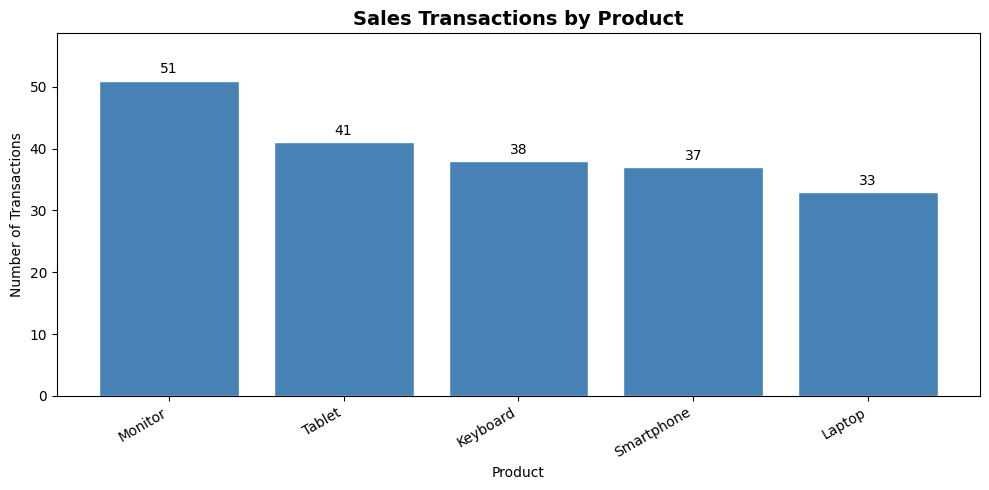

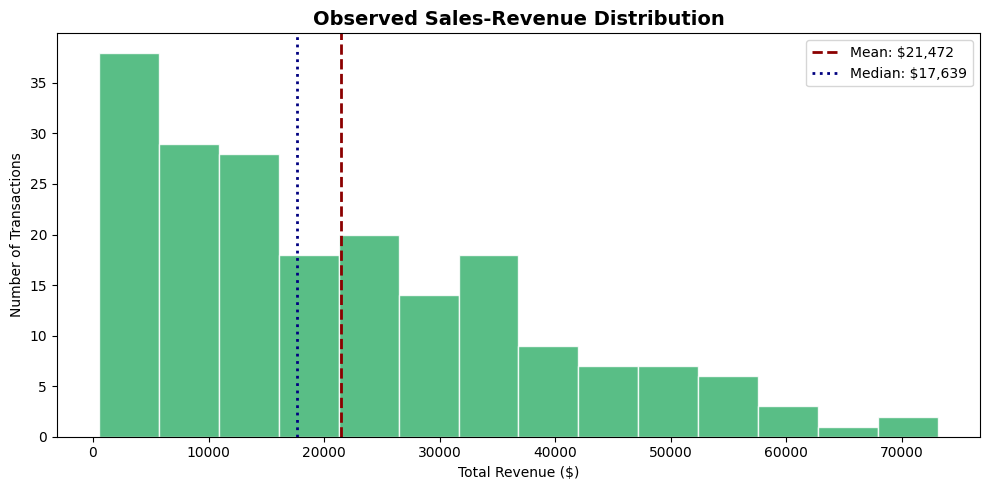

In [16]:

import pandas as pd
import matplotlib.pyplot as plt

# =====================================================
# MG628 WEEK 5 - FREQUENCY ANALYSIS AND HISTOGRAMS
# =====================================================

# Prepare the sales revenue data
revenue = pd.to_numeric(
    sales["Total Revenue"], errors="coerce"
).dropna()

# -----------------------------------------------------
# 1. PRODUCT FREQUENCY TABLE
# -----------------------------------------------------

product_counts = sales["Product"].value_counts()

frequency_table = (
    product_counts
    .rename_axis("Product")
    .to_frame("Count")
)

frequency_table["Percentage"] = (
    frequency_table["Count"] / frequency_table["Count"].sum() * 100
).round(2)

print("PRODUCT FREQUENCY DISTRIBUTION")
display(frequency_table)

# -----------------------------------------------------
# 2. BAR CHART - NUMBER OF TRANSACTIONS BY PRODUCT
# -----------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(
    product_counts.index,
    product_counts.values,
    color="steelblue",
    edgecolor="white"
)

# Display values above bars
ax.bar_label(bars, padding=3, fontsize=10)

ax.set_title(
    "Sales Transactions by Product",
    fontsize=14,
    fontweight="bold"
)
ax.set_xlabel("Product")
ax.set_ylabel("Number of Transactions")
ax.set_ylim(0, product_counts.max() * 1.15)

plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# -----------------------------------------------------
# 3. HISTOGRAM - DISTRIBUTION OF SALES REVENUE
# -----------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    revenue,
    bins=14,
    color="mediumseagreen",
    edgecolor="white",
    alpha=0.85
)

# Add mean and median reference lines
ax.axvline(
    revenue.mean(),
    color="darkred",
    linestyle="--",
    linewidth=2,
    label=f"Mean: ${revenue.mean():,.0f}"
)

ax.axvline(
    revenue.median(),
    color="navy",
    linestyle=":",
    linewidth=2,
    label=f"Median: ${revenue.median():,.0f}"
)

ax.set_title(
    "Observed Sales-Revenue Distribution",
    fontsize=14,
    fontweight="bold"
)
ax.set_xlabel("Total Revenue ($)")
ax.set_ylabel("Number of Transactions")

ax.legend()
plt.tight_layout()
plt.show()


## 5. Spread, standard deviation, quartiles and outliers

A center measure tells us where data cluster; **dispersion** tells us how stable or variable the observations are. Two departments can have identical average waiting times but very different experiences from one day to the next.

### Range

$$\text{Range}=\max(x)-\min(x).$$

Simple to calculate, but determined entirely by the two extreme values. It does not tell us how the remaining observations are distributed.

### Variance and standard deviation

For a *sample* of size $n$:

$$s^2=\frac{\sum_{i=1}^{n}(x_i-\bar{x})^2}{n-1},\qquad s=\sqrt{s^2}.$$

Each $x_i-\bar{x}$ is a **deviation** from the mean. Squaring prevents positive and negative deviations from cancelling out. **Sample variance** is measured in squared units (e.g., dollars squared), while **sample standard deviation** returns to the original units (dollars), making it easier to communicate.

For a full population, the variance instead uses denominator $N$ and center $\mu$. In this lab, we use **sample statistics** unless explicitly stated. Thus:

- Excel `VAR.S` ↔ pandas `.var(ddof=1)`.
- Excel `STDEV.S` ↔ pandas `.std(ddof=1)`.
- Excel `VAR.P` / `STDEV.P` ↔ pandas `.var(ddof=0)` / `.std(ddof=0)`.

### Worked comparison: same mean, different variability

| Facility | Five daily admissions | Mean | Sample SD (approx.) |
|---|---|---:|---:|
| A | 18, 19, 20, 21, 22 | 20 | 1.58 |
| B | 5, 10, 20, 30, 35 | 20 | 12.75 |

Both average **20 admissions**, but B varies much more, potentially requiring greater staffing flexibility. **This example is illustrative, not taken from the healthcare dataset.**

### Quartiles and interquartile range (IQR)

$Q_1$ is the 25th percentile, $Q_3$ the 75th percentile, and

$$\mathrm{IQR}=Q_3-Q_1.$$

The IQR describes the spread of the middle half of observed values and is less affected by very large or small values than the range.

A commonly used **outlier screening rule** is

$$\text{Lower fence}=Q_1-1.5(\mathrm{IQR}),\qquad \text{Upper fence}=Q_3+1.5(\mathrm{IQR}).$$

Values beyond these fences deserve investigation. **An outlier flag does not prove a data error** and must not automatically trigger deletion.

### Reading the box plot in the following cell

- The box extends from $Q_1$ to $Q_3$ (middle 50%).
- The line inside the box marks the median.
- With the standard `1.5 × IQR` setting, whiskers extend to the most extreme observed points within the fences; points beyond them are displayed separately.

**Quartile-convention note:** pandas `Series.quantile()` uses linear interpolation by default, broadly corresponding to Excel `QUARTILE.INC`/`PERCENTILE.INC` for these percentiles; `QUARTILE.EXC` uses a different convention and may give different values. Always align the convention when comparing Excel and Python.

**Managerial decision:** Is large variability an operational risk, normal seasonal variation, or an exceptional event? Descriptive statistics alone cannot establish the cause.

In [9]:
q1,q3=revenue.quantile([.25,.75]); iqr=q3-q1;low=q1-1.5*iqr;high=q3+1.5*iqr
summary=pd.Series({'n':revenue.count(),'mean':revenue.mean(),'median':revenue.median(),'min':revenue.min(),'max':revenue.max(),'range':revenue.max()-revenue.min(),'sample variance':revenue.var(ddof=1),'sample SD':revenue.std(ddof=1),'Q1':q1,'Q3':q3,'IQR':iqr,'lower fence':low,'upper fence':high,'skew':revenue.skew(),'excess kurtosis':revenue.kurt()});display(summary.round(3));print('Upper outliers:',sum(revenue>high))

,0
n,2.000000e+02
mean,2.147218e+04
median,1.763858e+04
min,5.105700e+02
max,7.313691e+04
range,7.262634e+04
sample variance,2.690129e+08
sample SD,1.640161e+04
Q1,8.712458e+03
Q3,3.191617e+04


Upper outliers: 2


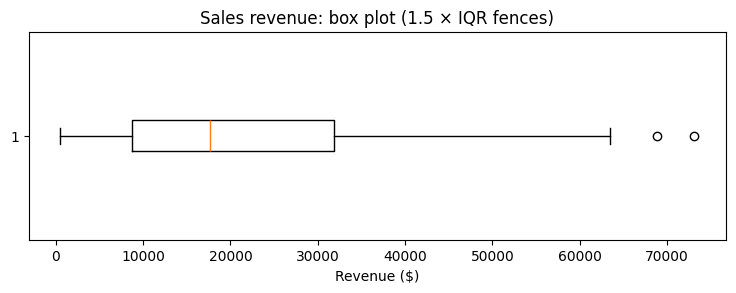

In [10]:
fig,ax=plt.subplots(figsize=(9,2.7));ax.boxplot(revenue,vert=False);ax.set(xlabel='Revenue ($)',title='Sales revenue: box plot (1.5 × IQR fences)');plt.show()

## 6. Healthcare case: transferring a statistical skill to another industry

The healthcare dataset provides fields such as `Department`, `Facility`, `Patient_Admissions`, and `Total_Billing`. The statistical calculations are the same as for sales, but their **managerial meaning** changes.

### Key distinctions

- **Mean admissions:** an average patient volume per recorded observation; it is **not automatically** an average per day unless every row represents a day.
- **Standard deviation of admissions:** how much admissions vary from record to record in a department; larger values imply less consistency, *not* necessarily poorer clinical performance.
- **Total billing:** the sum of recorded charges/billing amounts. Billing is **not the same as collections, costs, profit, or patient outcomes**.
- **Group size (`n`):** the number of observations in each department. Compare group sizes before interpreting a standard deviation based on only a few records.

The next cell groups records by department, calculates the observation count, mean admissions, sample SD of admissions, and sum of billing, then creates a chart of mean admissions. Pandas `groupby(...).agg(...)` is conceptually similar to an Excel PivotTable with Department in Rows and numeric fields in Values.

### A worked conceptual question

Suppose Department A and Department B both average 20 patient admissions per observation, but A has SD 2 and B has SD 12. B shows substantially greater variability and may benefit from flexible staffing capacity, reserve resources or a closer review of peaks. That statement is **a hypothesis for operational planning**, not proof that staff are underperforming.

**Interpretation exercise (after running):** Which department has the highest observed mean admissions? Does it also have the highest SD? Why should you avoid ranking departments solely by total billing? What other variables—such as case mix, capacity and time period—would improve the comparison?

,n,mean_admissions,sd_admissions,total_billing
Department,,,,
Cardiology,10,16.50,3.03,820490.10
Emergency,10,32.80,7.33,977719.25
Oncology,9,10.67,2.35,296555.51
Orthopedics,11,13.55,3.78,346548.24
Pediatrics,10,26.50,3.03,564562.02


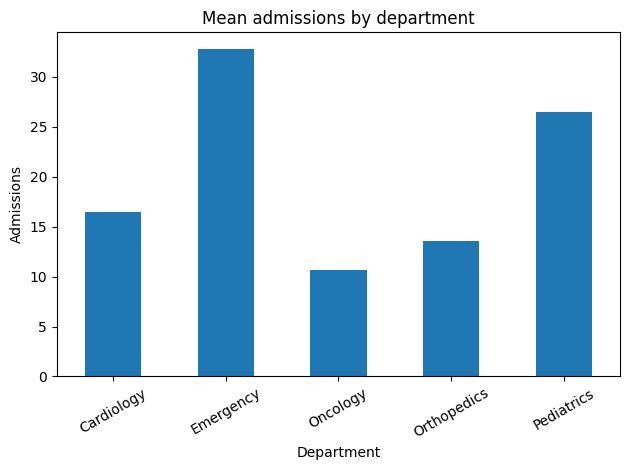

In [11]:
dept=health.groupby('Department').agg(n=('Patient_Admissions','size'),mean_admissions=('Patient_Admissions','mean'),sd_admissions=('Patient_Admissions','std'),total_billing=('Total_Billing','sum'));display(dept.round(2));dept['mean_admissions'].plot(kind='bar',title='Mean admissions by department',ylabel='Admissions',rot=30);plt.tight_layout();plt.show()

## 7. The normal distribution and the 68–95–99.7 empirical rule

A **normal distribution** is a continuous, bell-shaped, symmetric probability model. Its center is its mean $\mu$ and its spread is governed by standard deviation $\sigma$. A normal model is often useful for measurements produced by many small influences, but **you must check whether it reasonably describes your actual data**.

### Standard scores (z-scores)

A z-score measures how far a value $x$ is from the mean in standard-deviation units:

$$z=\frac{x-\mu}{\sigma}.$$

For example, if the mean is **100** and SD is **15**, then $x=130$ has $z=(130-100)/15=2$: it is two SDs above the mean.

### Empirical rule (normal distributions only)

When the distribution is approximately normal:

| Distance from mean | Approximate share | Example when $\mu=100$, $\sigma=15$ |
|---|---:|---|
| Within $\pm1\sigma$ | 68% | 85–115 |
| Within $\pm2\sigma$ | 95% | 70–130 |
| Within $\pm3\sigma$ | 99.7% | 55–145 |

The next cell calculates these boundaries. It does **not** test whether your sales data are normal, nor does it calculate empirical proportions from a dataset. The proportions above are properties of an *approximately normal model*.

**Misconception to avoid:** A distribution does not become normal merely because you can compute its mean and standard deviation. Strongly skewed sales revenue or healthcare billing may violate the assumptions behind the empirical rule.

**Discussion prompt:** If a manager treats a strongly right-skewed billing distribution as normal, how could the resulting forecasts of extreme values be misleading?

In [12]:
mu,sd=100,15
for k,p in [(1,'68%'),(2,'95%'),(3,'99.7%')]:print(p,mu-k*sd,mu+k*sd)

68% 85 115
95% 70 130
99.7% 55 145


## 8. Distribution shape: skewness and kurtosis (synthetic illustrations)

**Important distinction:** The `distributions` DataFrame contains **synthetically generated teaching examples** designed to display particular shapes. These are **not observed sales revenue or healthcare admissions**. Use them to learn how statistics behave; do not make empirical claims about businesses or patients from these figures.

### Skewness: which direction does the tail extend?

Skewness is a numerical description of **asymmetry**.

- **Near zero:** roughly symmetric, although a near-zero statistic alone does not guarantee a normal distribution.
- **Positive skewness:** a longer/heavier tail toward larger values (the **right** side). A few large revenue observations may raise the mean.
- **Negative skewness:** a longer/heavier tail toward smaller values (the **left** side).

The histogram panels display `Normal`, `Right_Skew` and `Left_Skew`. Compare the **tails**, not just the highest bar. Then compare their calculated mean, median and skewness in the summary table.

### Kurtosis: tail behavior and susceptibility to extremes

**Kurtosis** is related to the fourth standardized moment and is particularly sensitive to large deviations from the center. In applied teaching, it is more informative to discuss **tail heaviness and extreme observations** than simply “a tall peak versus a flat peak.”

This notebook uses **excess kurtosis** (the Fisher convention), for which a theoretical normal distribution has kurtosis **0**:

- **Mesokurtic:** reference normal-like tail behavior (excess kurtosis around 0).
- **Leptokurtic:** relatively heavier tails and typically more extreme values (positive excess kurtosis).
- **Platykurtic:** relatively lighter tails (negative excess kurtosis).

Finite samples do **not** have to produce exactly zero, positive or negative textbook values. A sample-based estimate varies even when its generating distribution is known.

**Excel ↔ Python:** Excel `SKEW()` and pandas `Series.skew()` use comparable adjusted sample skewness conventions; Excel `KURT()` and pandas `Series.kurt()` use adjusted **excess** kurtosis conventions. Compare calculations only when the same observations and missing-value rules are used.

**What the two upcoming figures do:** The first compares symmetry/right skew/left skew. The second compares mesokurtic, leptokurtic and platykurtic cases. Because sample kurtosis is sensitive to extremes, compare the chart *and* the numeric coefficient.

**Managerial interpretation:** An unusually heavy-tailed operational metric may deserve scenario planning and investigation of exceptional events. It does not by itself identify what causes those events.

,Normal,Right_Skew,Left_Skew,Mesokurtic,Leptokurtic,Platykurtic
mean,99.878,100.000,100.000,0.000,0.000,0.000
median,100.036,96.552,103.566,-0.015,-0.052,-0.068
std,14.824,15.000,15.000,1.000,1.000,1.000
skew,-0.039,0.952,-0.999,0.000,-0.165,0.048
kurt,0.353,0.799,0.727,-0.192,2.756,-1.169


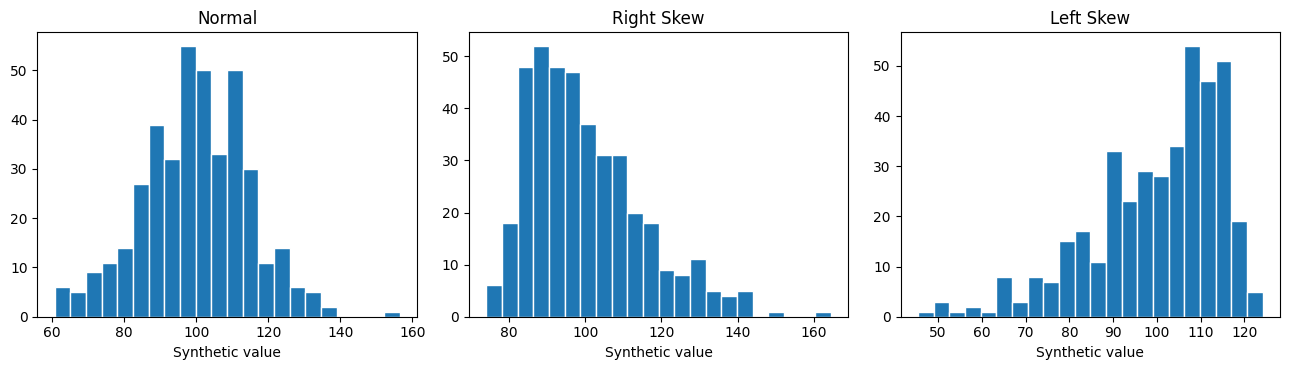

In [13]:
display(distributions.agg(['mean','median','std','skew','kurt']).round(3))
fig,axs=plt.subplots(1,3,figsize=(13,3.8));
for ax,col in zip(axs,['Normal','Right_Skew','Left_Skew']):ax.hist(distributions[col],bins=22,edgecolor='white');ax.set_title(col.replace('_',' '));ax.set_xlabel('Synthetic value')
plt.tight_layout();plt.show()

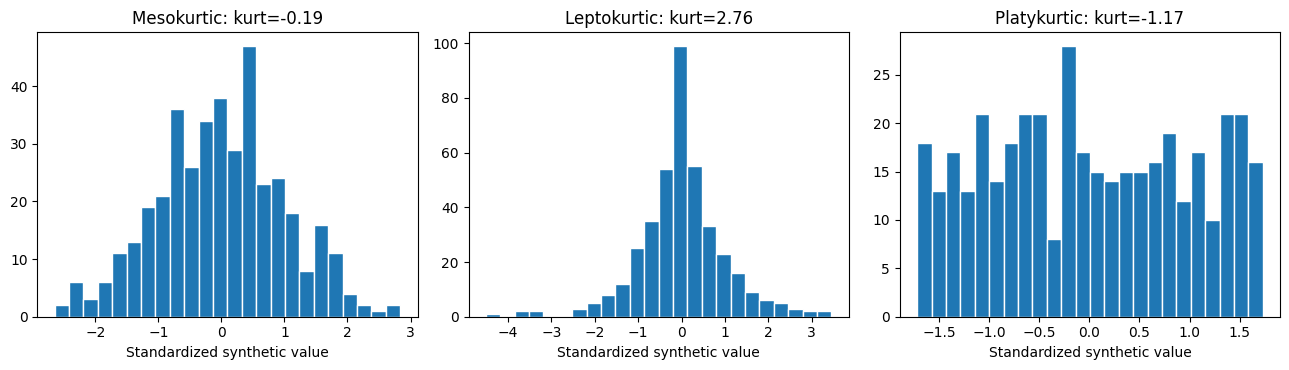

In [14]:
fig,axs=plt.subplots(1,3,figsize=(13,3.8));
for ax,col in zip(axs,['Mesokurtic','Leptokurtic','Platykurtic']):ax.hist(distributions[col],bins=24,edgecolor='white');ax.set_title(f'{col}: kurt={distributions[col].kurt():.2f}');ax.set_xlabel('Standardized synthetic value')
plt.tight_layout();plt.show()

## 9. Excel ↔ Python cross-check: validation before interpretation

The value of two tools is not that they produce two different answers—it is that **independently implemented methods can confirm the same statistical result**.

The next code cell compares observed sales-revenue results with independently established reference benchmarks from the canonical 200-row sales dataset:

| Metric | Expected rounded result | Excel | Python |
|---|---:|---|---|
| Mean sales revenue | $21,472.18 | `AVERAGE` | `.mean()` |
| Median sales revenue | $17,638.58 | `MEDIAN` | `.median()` |
| Sample SD of revenue | $16,401.61 | `STDEV.S` | `.std(ddof=1)` |

These values are **reference results for this particular CSV**. They will change if the input file changes. The code checks the observed outputs to the displayed precision, and raises an assertion error if a mismatch is large enough to require investigation.

### Diagnostic sequence when answers disagree

1. **Same dataset?** Confirm filenames and number of rows.
2. **Same variable?** `Units Sold`, `Unit Price` and `Total Revenue` measure different things.
3. **Same subset?** Compare filters, date ranges and group definitions.
4. **Same data types?** Numeric-looking text may be ignored or interpreted differently.
5. **Same missing-value rule?** Check blanks, zero values and invalid entries.
6. **Same statistical formula?** `STDEV.S` corresponds to `ddof=1`, not `ddof=0`.
7. **Same percentile/kurtosis convention?** `QUARTILE.INC` differs from `QUARTILE.EXC`; kurtosis may be raw or excess.
8. **Same rounding?** Compare unrounded values first, then apply a sensible reporting precision.

**Never “fix” an unexpected answer by overwriting it with a known benchmark.** Determine why the new result differs. Benchmarks are safeguards, not replacements for analysis.

**Reflection question:** Which discrepancy is more concerning: a $0.01 rounding difference or a 10% difference in standard deviation? What would you investigate first?

In [15]:
expected={'mean':21472.18,'median':17638.58,'sample_sd':16401.61}
actual={'mean':revenue.mean(),'median':revenue.median(),'sample_sd':revenue.std(ddof=1)}
for k in expected:print(k,round(actual[k],2),'PASS' if abs(round(actual[k],2)-expected[k])<.011 else 'VERIFY SOURCE')
assert all(abs(round(actual[k],2)-expected[k])<.011 for k in expected)

mean 21472.18 PASS
median 17638.58 PASS
sample_sd 16401.61 PASS


## 10. Student challenge: calculate → describe → decide

Complete these questions *after* running all prior cells. For every quantitative response, include **(a) the statistic and units, (b) what the result describes, and (c) a practical managerial implication**. Distinguish conclusions supported by these data from hypotheses needing more investigation.

### A. Sales management

1. **Typical transaction:** Report the mean and median `Total Revenue` and explain why they differ. Which better represents a typical sale when a minority of transactions have very high values? Why might management still need the mean?
2. **Product mix:** Use `sales['Product'].value_counts()` to identify the most frequently observed product. Compute that product's share of all sales records. *Does the most frequent product necessarily generate the most revenue?* Propose a second calculation to test that question.
3. **Revenue volatility:** Report the sample SD of `Total Revenue`. Explain why it is expressed in dollars, whereas variance is measured in dollars squared.
4. **Extreme transactions:** Compute the IQR-based upper fence. How many observations exceed it? Give **two plausible explanations** for an extreme transaction and describe how you would verify them.
5. **Graph selection:** Explain which managerial question is better answered with a product frequency bar chart versus a revenue histogram.

### B. Healthcare application

6. **Department comparison:** From the grouped table, choose two departments and report each one's mean admissions and sample SD, along with `n`. Which department shows greater variation in observed admissions? Explain *without assuming the observations represent consecutive days*.
7. **Avoiding causal claims:** Is the department with the highest `Total_Billing` necessarily the least efficient? Identify at least **three** additional factors that could affect the result.
8. **Operational decision:** Draft a three-sentence note to a hospital administrator explaining what variability reveals, what it does not establish, and one follow-up analysis.

### C. Understanding distributions

9. **Empirical rule:** For $\mu=100$ and $\sigma=15$, give the approximate intervals containing 68%, 95% and 99.7% of outcomes **if a normal model is appropriate**. Explain why these bounds should not be mechanically applied to observed sales revenue.
10. **Skewness and kurtosis:** Describe the visual difference between the synthetic right-skew and left-skew plots. Then explain why excess kurtosis concerns the potential for extremes rather than simply peak height.

### D. Excel/Python validation

11. **Formula mapping:** Write the Excel and pandas operations for mean, median, sample variance, sample SD, Q1, Q3, skewness and excess kurtosis.
12. **Troubleshooting:** Suppose Excel and Python disagree on SD. Write a short, ordered debugging checklist; include sample/population denominator, filters, blank cells and numeric data types.

### Suggested response rubric (20 points)

| Dimension | Points | Evidence |
|---|---:|---|
| Correct calculations and units | 8 | Relevant numerical results with an appropriate statistical definition |
| Interpretation of center, spread and shape | 6 | Explains rather than merely repeats values |
| Managerial recommendation and limitations | 4 | Actionable next question; avoids causal overstatement |
| Excel ↔ Python method reconciliation | 2 | Correct function mapping and cross-check logic |

**Exit ticket:** *Two departments have the same average admissions but very different standard deviations. What additional question would you ask before recommending a staffing change?*